# 50017L 50034R
 - middle and large contact areas

In [4]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [5]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/meshInd') # path to parent of output_root in set_parameters
study_prefix = 'study2' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs/meshInd-{study_prefix}') # path dir to save outputs in
suffixes = ['a', 'b', 'c', 'd'] # individual study identifier (end of dir name of output_root in set_parameters)

In [6]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
extra_params = [
    'cgal_params.optimisation.odt',
    'cgal_params.optimisation.lloyd',
    ]
get_params3d(root_dir, study_prefix, suffixes, extra_params).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [7]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [139]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'
qual_part2 = 'cart_inner'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        f'{qual_part2}_min_angle_worst',
        f'{qual_part2}_scaled_jacobian_worst',
        f'{qual_part2}_aspect_ratio_worst',
        f'{qual_part2}_radius_ratio_worst',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)
df = df[(df['bone_remesh2d_di_max']<0.1)&(df['cart_remesh2d_di_max']<0.1)&(df['full_scaled_jacobian_worst']>0.04)] # remove any where odt chipped tets

#df = df[df['bone']==bone]

print(len(df))

171


Highest element count:
	50034R - 278916


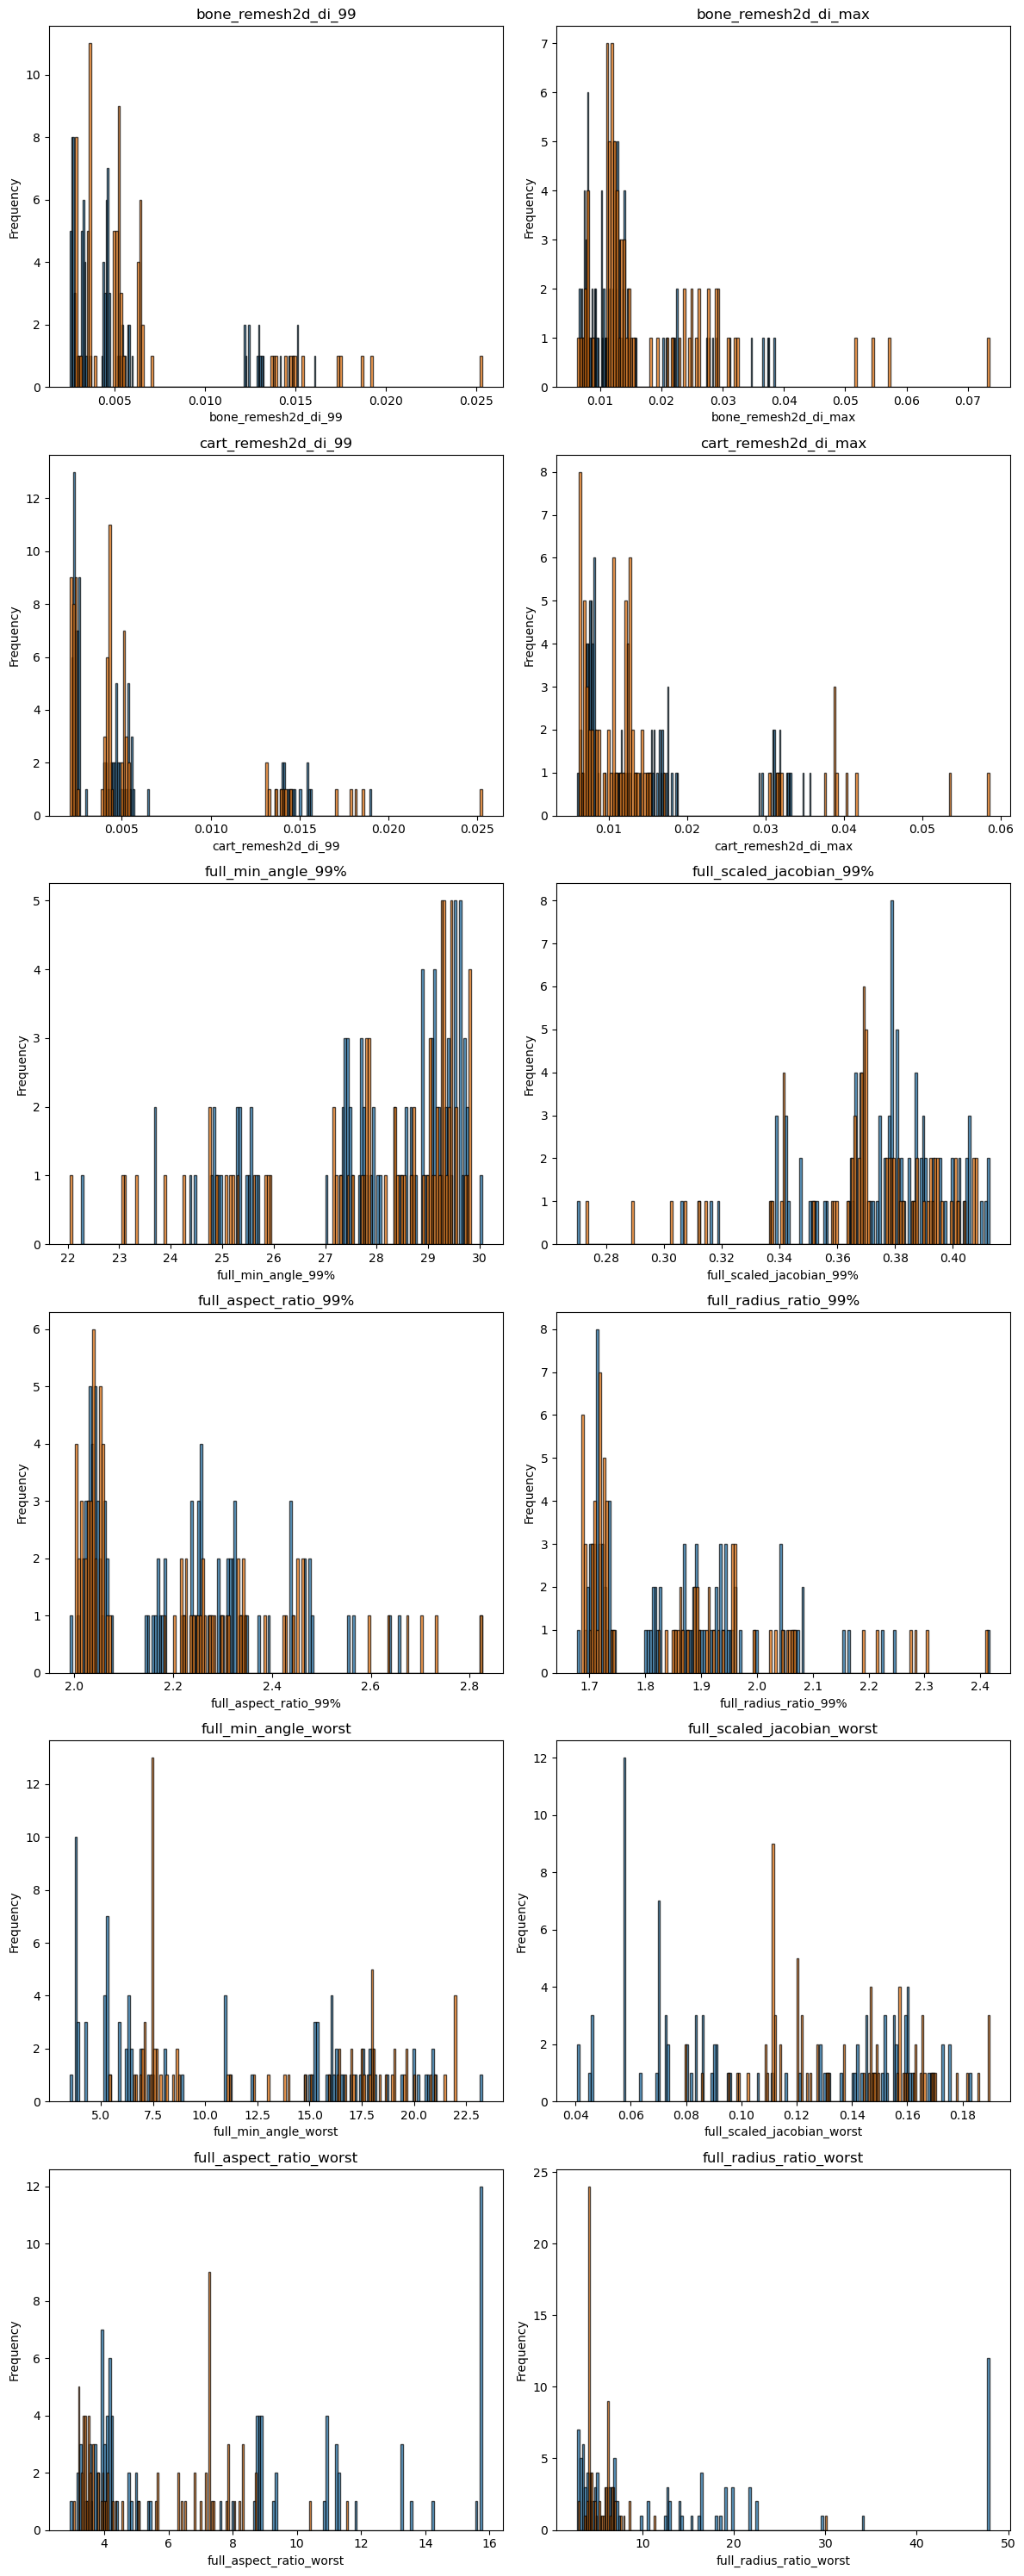

In [140]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 1)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [141]:
q1_weight = 10
q2_weight = 25
q3_weight = 50

chosen_metrics = {

    f'{qual_part2}_min_angle_worst': {
        'ideal': 20,
        'acceptable': 15,
        'weight': q3_weight
    },

    f'{qual_part2}_scaled_jacobian_worst': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q3_weight
    },

    f'{qual_part2}_aspect_ratio_worst': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q3_weight
    },

    f'{qual_part2}_radius_ratio_worst': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q3_weight
    },




    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q2_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q2_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q2_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q2_weight
    },

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q1_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q1_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q1_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q1_weight
    },
}

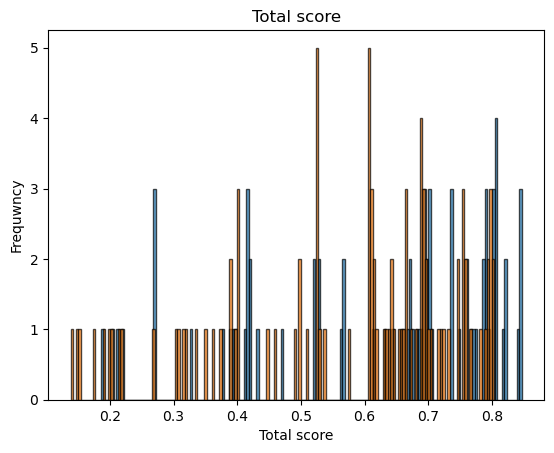

In [142]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_qual.merge(
    df_score,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/1), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    #ax.legend()

In [143]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank.head(10)

,cgal_params.optimisation.odt,cgal_params.optimisation.lloyd,cgal_params.sizing_field.n_tets,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound,mean_rank,median_rank,best_rank,n_runs
54,True,False,3,20.0,0.0001,NaN,NaN,7.666667,7.0,1.0,3
6,False,True,1,NaN,NaN,10.0,0.0100,12.333333,9.0,9.0,3
57,True,False,3,20.0,0.0100,NaN,NaN,12.333333,13.0,6.0,3
16,False,True,2,NaN,NaN,10.0,0.0010,12.666667,10.0,3.0,3
58,True,False,3,30.0,0.0001,NaN,NaN,13.333333,8.0,8.0,3
61,True,False,3,30.0,0.0100,NaN,NaN,13.666667,15.0,9.0,3
5,False,True,1,NaN,NaN,10.0,0.0010,13.666667,8.0,6.0,3
55,True,False,3,20.0,0.0005,NaN,NaN,13.666667,14.0,10.0,3
14,False,True,2,NaN,NaN,10.0,0.0001,13.666667,13.0,2.0,3
53,True,False,3,10.0,0.0100,NaN,NaN,14.000000,16.0,4.0,3


In [144]:
best_per_tet = df_score_param.groupby(['cgal_params.sizing_field.n_tets', 'sub', 'bone']).first()
best_per_tet

run_id  \
cgal_params.sizing_field.n_tets sub    bone              
1                               50017L mc1    0-0-0-0b   
                                       tpm    0-0-1-0b   
                                50034R mc1   0-0-12-0d   
                                       tpm    0-0-6-0d   
2                               50017L mc1   0-0-17-0b   
                                       tpm   0-0-24-0b   
                                50034R mc1   0-0-16-0d   
                                       tpm   0-0-14-0c   
3                               50017L mc1   0-0-31-0a   
                                       tpm   0-0-38-0b   
                                50034R mc1   0-0-34-0d   
                                       tpm   0-0-31-0c   

                                             cart_inner_min_angle_worst  \
cgal_params.sizing_field.n_tets sub    bone                               
1                               50017L mc1                     1.000000   
                                       tpm                     1.000000   
                                50034R mc1                     1.000000   
                                       tpm                     1.000000   
2                               50017L mc1                     0.851916   
                                       tpm                     1.000000   
                                50034R mc1                     0.800501   
                                       tpm                     0.997957   
3                               50017L mc1                     1.000000   
                                       tpm                     0.945710   
                                50034R mc1                     0.902814   
                                       tpm                     1.000000   

                                             cart_inner_scaled_jacobian_worst  \
cgal_params.sizing_field.n_tets sub    bone                                     
1                               50017L mc1                           1.000000   
                                       tpm                           1.000000   
                                50034R mc1                           0.459549   
                                       tpm                           0.847766   
2                               50017L mc1                           0.434275   
                                       tpm                           0.357267   
                                50034R mc1                           0.453171   
                                       tpm                           0.536843   
3                               50017L mc1                           0.033723   
                                       tpm                           0.005350   
                                50034R mc1                           0.130549   
                                       tpm                           0.069274   

                                             cart_inner_aspect_ratio_worst  \
cgal_params.sizing_field.n_tets sub    bone                                  
1                               50017L mc1                        1.000000   
                                       tpm                        1.000000   
                                50034R mc1                        1.000000   
                                       tpm                        1.000000   
2                               50017L mc1                        0.788584   
                                       tpm                        0.870249   
                                50034R mc1                        0.807588   
                                       tpm                        0.925539   
3                               50017L mc1                        1.000000   
                                       tpm                        0.709586   
                                50034R mc1                        0.804575   
                                   

In [145]:
best_per_tet.merge(df_score_qual)[['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if '_x' in x]]

,sub,bone,run_id,full_min_angle_worst_x,full_min_angle_99%_x,full_radius_ratio_worst_x,full_radius_ratio_99%_x,full_aspect_ratio_worst_x,full_aspect_ratio_99%_x,full_scaled_jacobian_worst_x,full_scaled_jacobian_99%_x,cart_inner_min_angle_worst_x,cart_inner_radius_ratio_worst_x,cart_inner_aspect_ratio_worst_x,cart_inner_scaled_jacobian_worst_x
0,50017L,mc1,0-0-0-0b,6.358659,24.927664,12.440516,2.075056,8.649722,2.481284,0.089714,0.336926,32.100011,1.668531,2.043155,0.425428
1,50017L,tpm,0-0-1-0b,4.239339,24.807213,19.885717,2.070545,13.241548,2.466058,0.045641,0.343376,34.960115,1.650610,1.914415,0.448382
2,50034R,mc1,0-0-12-0d,16.710568,23.042630,3.774969,2.276091,4.116140,2.673082,0.095053,0.289054,23.593316,2.070584,2.533888,0.297188
3,50034R,tpm,0-0-6-0d,8.189969,24.895870,6.965612,2.023485,7.884197,2.424661,0.102644,0.340610,34.934894,1.628534,1.931257,0.369553
4,50017L,mc1,0-0-17-0b,17.997604,27.924868,3.433156,1.871662,3.919379,2.239709,0.130758,0.393037,18.519158,2.811354,3.422832,0.295302
5,50017L,tpm,0-0-24-0b,20.005353,28.500180,5.186861,1.801509,3.533516,2.147348,0.148702,0.403934,20.017986,2.779355,3.259502,0.288796
6,50034R,mc1,0-0-16-0d,16.362286,27.815420,4.068062,1.893769,3.815434,2.261027,0.148620,0.392098,18.005010,2.798784,3.384825,0.296722
7,50034R,tpm,0-0-14-0c,19.005450,29.343930,4.167058,1.715521,3.358387,2.037366,0.159124,0.369741,19.979569,2.619202,3.148922,0.307369
8,50017L,mc1,0-0-31-0a,23.273274,30.054166,2.844679,1.677961,2.925226,1.991498,0.183162,0.378955,24.003215,2.356648,2.793701,0.210119
9,50017L,tpm,0-0-38-0b,19.457105,24.490951,3.329449,2.155970,3.580827,2.556729,0.140132,0.318550,19.457105,3.257212,3.580827,0.148748
